# 한국어 토크나이저 비교 실험

**데이터**: 국방일보 PDF 코퍼스 (`kookbang_corpus.txt`, ~31MB)

**실험 항목**
1. BPE 토크나이저 학습 및 평가
2. WordPiece 토크나이저 학습 및 평가
3. 한국어 형태소 분석기 (Mecab / Okt / Kkma) 비교 평가

**평가 지표**
- 어휘 크기 (Vocab Size)
- OOV 비율 (Unknown Token Rate)
- Fertility (원문 어절 대비 평균 토큰 수)
- 토크나이징 속도 (k tokens/sec)

**학습 데이터 크기 조건**: 전체의 10% / 50% / 100%

In [1]:
# 필요 라이브러리 설치
# !pip install tokenizers konlpy matplotlib pandas

In [2]:
import time, random
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from tokenizers import Tokenizer
from tokenizers.models import BPE, WordPiece
from tokenizers.trainers import BpeTrainer, WordPieceTrainer
from tokenizers.pre_tokenizers import Whitespace

matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

CORPUS_PATH = Path('data/kookbang_corpus.txt')
SPLIT_DIR   = Path('data/splits')
MODEL_DIR   = Path('models')
RESULT_DIR  = Path('results')

for d in [SPLIT_DIR, MODEL_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# BPE: 학습 데이터 100% 기준 고유 음절 수 = 6,570개
#      merge가 발생하려면 vocab_size > 고유 문자 수 이어야 함
#      → 최솟값: 7,000
BPE_VOCAB_SIZE = 7000

# WordPiece: 연속 토큰에 ## 접두사를 붙이므로 동일 문자도 2종류로 저장
#            ('국' 과 '##국' 을 별개 토큰으로 취급)
#            → 실제 필요 vocab ≈ 고유 음절 수 × 2 ≈ 11,700개 이상
#            → 최솟값: 12,000
WP_VOCAB_SIZE  = 12000

RATIOS      = [0.10, 0.50, 1.00]
RATIO_NAMES = ['10%', '50%', '100%']

print(f'BPE vocab size: {BPE_VOCAB_SIZE}')
print(f'WP  vocab size: {WP_VOCAB_SIZE}')
print('설정 완료')

BPE vocab size: 7000
WP  vocab size: 12000
설정 완료


## 1. 데이터 준비

In [3]:
with open(CORPUS_PATH, encoding='utf-8') as f:
    full_lines = [line.strip() for line in f if line.strip()]

random.seed(42)
random.shuffle(full_lines)

print(f'전체 줄 수: {len(full_lines):,}')
print(f'전체 용량: {CORPUS_PATH.stat().st_size / 1024 / 1024:.2f} MB')

전체 줄 수: 679,524
전체 용량: 29.71 MB


In [4]:
# 평가셋 분리 (~1.5KB)
eval_lines, eval_chars = [], 0
for line in full_lines:
    eval_lines.append(line)
    eval_chars += len(line)
    if eval_chars >= 1500:
        break

train_lines = full_lines[len(eval_lines):]
eval_text   = '\n'.join(eval_lines)

with open('eval_set.txt', 'w', encoding='utf-8') as f:
    f.write(eval_text)

print(f'평가셋: {len(eval_lines)}줄, {len(eval_text.encode())} bytes')
print(f'학습셋: {len(train_lines):,}줄')
print('\n--- 평가셋 미리보기 ---')
print(eval_text[:300])

평가셋: 92줄, 4201 bytes
학습셋: 679,432줄

--- 평가셋 미리보기 ---
병
국군의날행사때도보부대분열과시가행진에참가
식물을조리하는것이아니라, 식수신청
논의할예정이다.
보했다. 2열승객을위한시트백리클라이닝각도증대
능을제공해보안성을한층높였다.
하지못했으나항일투쟁동지로선높이평가
면신속정확한화력지원은필수요소"라
젤렌스키대통령은26일(현지시간) 프
국방대, 나토국방대방한단환영행사
아이는경찰이책임을져야지"라고말하는식
제16905호
의
대회장이었던백선엽장군의부인노인숙
이번교육과정을함께한13명의외국
심어줘야하는'교수자'로서의사명은
을소개하며방산육성을강조하기도했다.
인명구조법숙달·적응력배양
담당자의주기적방문이어려운지역의


In [5]:
# 10% / 50% / 100% 분할 저장
split_paths = {}
for ratio, name in zip(RATIOS, RATIO_NAMES):
    n    = max(1, int(len(train_lines) * ratio))
    path = SPLIT_DIR / f'train_{name}.txt'
    with open(path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(train_lines[:n]))
    split_paths[name] = path
    print(f'[{name:>4}] {n:>7,}줄 | {path.stat().st_size/1024/1024:.2f} MB -> {path}')

[ 10%]  67,943줄 | 2.98 MB -> data/splits/train_10%.txt
[ 50%] 339,716줄 | 14.85 MB -> data/splits/train_50%.txt
[100%] 679,432줄 | 29.70 MB -> data/splits/train_100%.txt


## 2. BPE 알고리즘 직접 구현 (원리 이해)

### 동작 순서
1. 말뭉치를 단어 단위로 pre-tokenize → 빈도 계산
2. 각 단어를 글자(character) 단위로 분할 → 초기 vocab 구성
3. 가장 자주 등장하는 인접 쌍(pair)을 찾아 병합 → vocab에 추가
4. vocab_size에 도달할 때까지 반복
5. 학습된 merge rules로 새 텍스트를 토크나이징

## 2. 평가 함수 정의

| 지표 | 설명 |
|------|------|
| Vocab Size | 학습된 어휘 크기 |
| OOV Rate (%) | 평가셋에서 `[UNK]` 토큰 비율 |
| Fertility | 토큰 수 / 공백 기준 어절 수 |
| Speed (k tok/s) | 초당 토크나이징 토큰 수 |

In [6]:
def evaluate_subword(tokenizer, eval_lines):
    UNK_ID = tokenizer.token_to_id('[UNK]')

    start     = time.perf_counter()
    encodings = [tokenizer.encode(line) for line in eval_lines]
    elapsed   = time.perf_counter() - start

    all_ids      = [tid for enc in encodings for tid in enc.ids]
    total_tokens = len(all_ids)
    oov_count    = all_ids.count(UNK_ID) if UNK_ID is not None else 0
    total_words  = sum(len(line.split()) for line in eval_lines)

    return {
        'vocab_size' : tokenizer.get_vocab_size(),
        'oov_rate'   : round(oov_count / total_tokens * 100, 2) if total_tokens else 0,
        'fertility'  : round(total_tokens / total_words, 3) if total_words else 0,
        'speed_ktps' : round(total_tokens / elapsed / 1000, 1) if elapsed > 0 else 0,
    }


def evaluate_morpheme(tagger, eval_lines, strict_filter=False):
    if strict_filter:
        # Kkma용: 10글자 이상 + 한글 30% 이상만
        safe_lines = [line for line in eval_lines
                      if len(line.strip()) >= 10 and
                      len([c for c in line if '가' <= c <= '힣']) / len(line) >= 0.3]
    else:
        # Mecab, Okt용: 5글자 이상만
        safe_lines = [line for line in eval_lines if len(line.strip()) >= 5]

    start        = time.perf_counter()
    total_morphs = 0
    errors       = 0

    for line in safe_lines:
        try:
            total_morphs += len(tagger.morphs(line))
        except Exception:
            errors += 1

    elapsed     = time.perf_counter() - start
    total_words = sum(len(line.split()) for line in safe_lines)

    if errors:
        print(f'  [경고] {errors}줄 스킵됨')

    return {
        'fertility'  : round(total_morphs / total_words, 3) if total_words else 0,
        'speed_ktps' : round(total_morphs / elapsed / 1000, 1) if elapsed > 0 else 0,
        'elapsed_sec': round(elapsed, 2),
    }

## 3. BPE 토크나이저

In [ ]:
bpe_results = []

for ratio, name in zip(RATIOS, RATIO_NAMES):
    tokenizer = Tokenizer(BPE(unk_token='[UNK]'))
    tokenizer.pre_tokenizer = Whitespace()
    trainer = BpeTrainer(
        vocab_size=BPE_VOCAB_SIZE,
        special_tokens=['[UNK]', '[PAD]', '[CLS]', '[SEP]', '[MASK]'],
        min_frequency=1,
    )

    t0 = time.perf_counter()
    tokenizer.train([str(split_paths[name])], trainer)
    train_sec = round(time.perf_counter() - t0, 2)

    tokenizer.save(str(MODEL_DIR / f'bpe_{name}.json'))

    m = evaluate_subword(tokenizer, eval_lines)
    m.update({'ratio': name, 'train_sec': train_sec})
    bpe_results.append(m)
    print(f'[BPE {name}] 학습 {train_sec}s | vocab={m["vocab_size"]:,} | '
          f'OOV={m["oov_rate"]}% | fertility={m["fertility"]} | speed={m["speed_ktps"]}k tok/s')

df_bpe = pd.DataFrame(bpe_results).set_index('ratio')
print('\n=== BPE 결과 ===')
print(df_bpe[['vocab_size', 'oov_rate', 'fertility', 'speed_ktps', 'train_sec']])




[BPE 10%] 학습 0.67s | vocab=7,000 | OOV=0.0% | fertility=7.966 | speed=1117.8k tok/s



[BPE 50%] 학습 2.18s | vocab=7,000 | OOV=0.0% | fertility=8.866 | speed=1333.5k tok/s



[BPE 100%] 학습 3.49s | vocab=7,000 | OOV=0.0% | fertility=10.235 | speed=811.9k tok/s

=== BPE 결과 ===
       vocab_size  oov_rate  fertility  speed_ktps  train_sec
ratio                                                        
10%          7000       0.0      7.966      1117.8       0.67
50%          7000       0.0      8.866      1333.5       2.18
100%         7000       0.0     10.235       811.9       3.49


## 4. WordPiece 토크나이저

In [ ]:
wp_results = []

for ratio, name in zip(RATIOS, RATIO_NAMES):
    tokenizer = Tokenizer(WordPiece(unk_token='[UNK]'))
    tokenizer.pre_tokenizer = Whitespace()
    trainer = WordPieceTrainer(
        vocab_size=WP_VOCAB_SIZE,
        special_tokens=['[UNK]', '[PAD]', '[CLS]', '[SEP]', '[MASK]'],
        min_frequency=2,
    )

    t0 = time.perf_counter()
    tokenizer.train([str(split_paths[name])], trainer)
    train_sec = round(time.perf_counter() - t0, 2)

    tokenizer.save(str(MODEL_DIR / f'wordpiece_{name}.json'))

    m = evaluate_subword(tokenizer, eval_lines)
    m.update({'ratio': name, 'train_sec': train_sec})
    wp_results.append(m)
    print(f'[WP  {name}] 학습 {train_sec}s | vocab={m["vocab_size"]:,} | '
          f'OOV={m["oov_rate"]}% | fertility={m["fertility"]} | speed={m["speed_ktps"]}k tok/s')

df_wp = pd.DataFrame(wp_results).set_index('ratio')
print('\n=== WordPiece 결과 ===')
print(df_wp[['vocab_size', 'oov_rate', 'fertility', 'speed_ktps', 'train_sec']])




[WP  10%] 학습 0.9s | vocab=12,000 | OOV=0.0% | fertility=7.739 | speed=1108.0k tok/s



[WP  50%] 학습 2.46s | vocab=12,000 | OOV=0.0% | fertility=8.765 | speed=873.4k tok/s



[WP  100%] 학습 3.58s | vocab=12,000 | OOV=0.0% | fertility=10.639 | speed=388.7k tok/s

=== WordPiece 결과 ===
       vocab_size  oov_rate  fertility  speed_ktps  train_sec
ratio                                                        
10%         12000       0.0      7.739      1108.0       0.90
50%         12000       0.0      8.765       873.4       2.46
100%        12000       0.0     10.639       388.7       3.58


## 5. 한국어 형태소 분석기 비교 (Mecab / Okt / Kkma)

> 형태소 분석기는 별도 학습 없이 평가셋으로 속도 / Fertility를 비교합니다.

In [9]:
from konlpy.tag import Okt, Kkma
from mecab import MeCab

okt   = Okt()
kkma  = Kkma()
mecab = MeCab()

print('Okt, Kkma, Mecab 로드 완료')
print('Mecab 테스트:', mecab.morphs('대한민국 육군은 최전방에서 임무를 수행한다.'))

Okt, Kkma, Mecab 로드 완료
Mecab 테스트: ['대한민국', '육군', '은', '최', '전방', '에서', '임무', '를', '수행', '한다', '.']


In [10]:
morph_results = {}
print('형태소 분석기 평가 중 (Kkma는 느릴 수 있음)...')

for tname, tagger in [('Mecab', mecab), ('Okt', okt)]:
    r = evaluate_morpheme(tagger, eval_lines, strict_filter=False)
    morph_results[tname] = r
    print(f'[{tname:<5}] fertility={r["fertility"]} | speed={r["speed_ktps"]}k tok/s | {r["elapsed_sec"]}s')

r = evaluate_morpheme(kkma, eval_lines, strict_filter=True) 
morph_results['Kkma'] = r
df_morph = pd.DataFrame(morph_results).T
print('\n=== 형태소 분석기 결과 ===')
print(df_morph[['fertility', 'speed_ktps', 'elapsed_sec']])

형태소 분석기 평가 중 (Kkma는 느릴 수 있음)...
[Mecab] fertility=8.212 | speed=4.7k tok/s | 0.2s
[Okt  ] fertility=6.991 | speed=0.7k tok/s | 1.11s

=== 형태소 분석기 결과 ===
       fertility  speed_ktps  elapsed_sec
Mecab      8.212         4.7         0.20
Okt        6.991         0.7         1.11
Kkma       9.180         0.4         2.25


## 6. 결과 비교 시각화

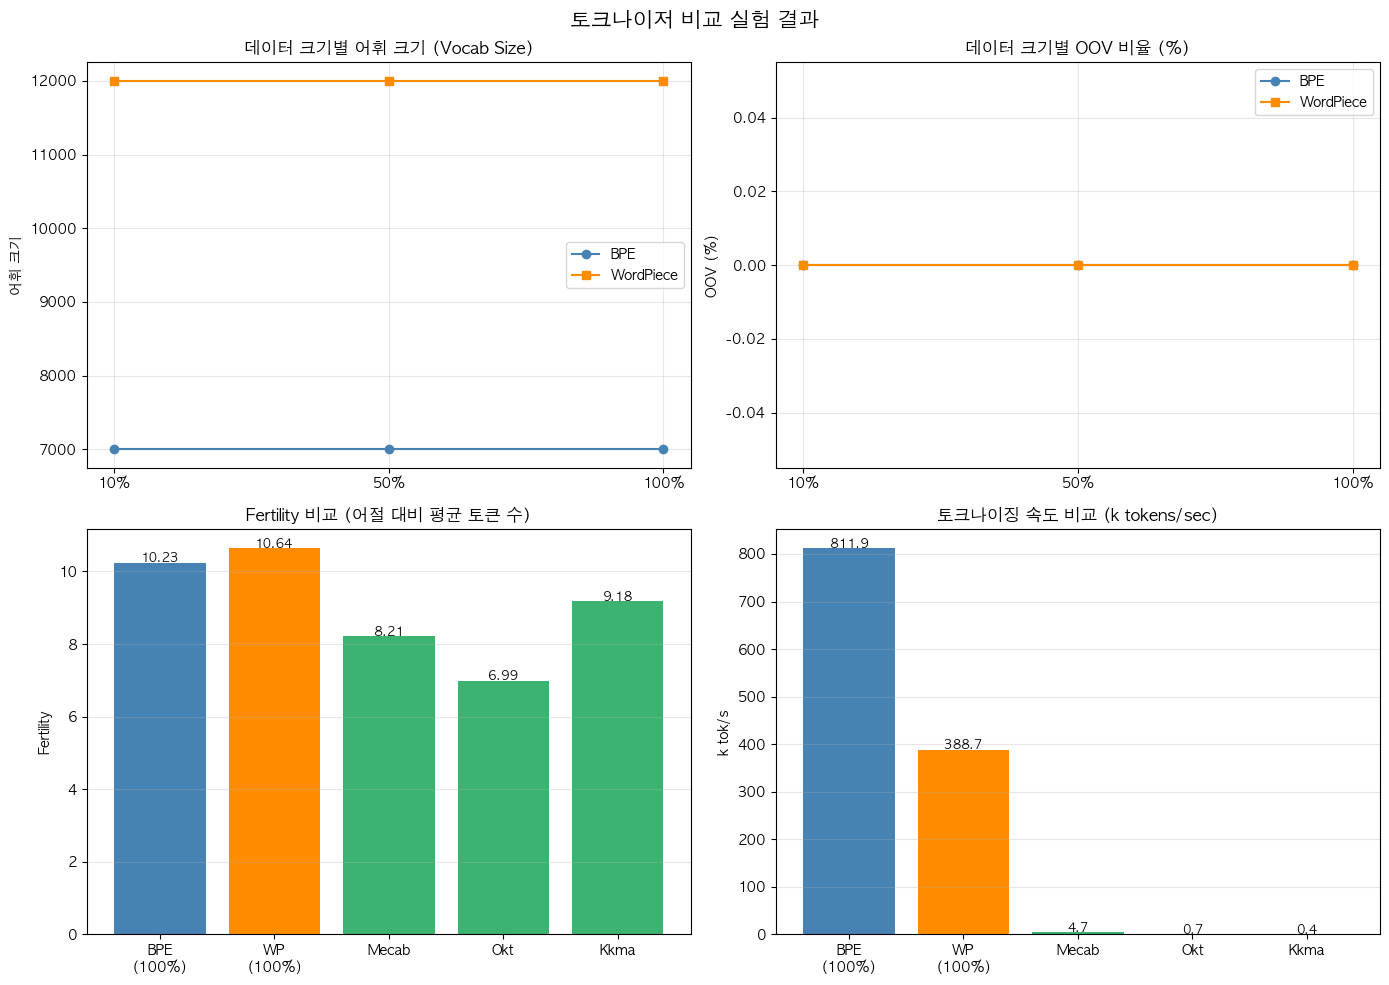

저장: tokenizer_comparison.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('토크나이저 비교 실험 결과', fontsize=15, fontweight='bold')

# (1) 어휘 크기
ax = axes[0, 0]
ax.plot(RATIO_NAMES, df_bpe['vocab_size'], 'o-', label='BPE',       color='steelblue')
ax.plot(RATIO_NAMES, df_wp['vocab_size'],  's-', label='WordPiece', color='darkorange')
ax.set_title('데이터 크기별 어휘 크기 (Vocab Size)')
ax.set_ylabel('어휘 크기'); ax.legend(); ax.grid(True, alpha=0.3)

# (2) OOV 비율
ax = axes[0, 1]
ax.plot(RATIO_NAMES, df_bpe['oov_rate'], 'o-', label='BPE',       color='steelblue')
ax.plot(RATIO_NAMES, df_wp['oov_rate'],  's-', label='WordPiece', color='darkorange')
ax.set_title('데이터 크기별 OOV 비율 (%)')
ax.set_ylabel('OOV (%)'); ax.legend(); ax.grid(True, alpha=0.3)

# (3) Fertility 막대 비교 (100% + 형태소)
bar_names  = ['BPE\n(100%)', 'WP\n(100%)'] + list(morph_results.keys())
bar_colors = ['steelblue', 'darkorange'] + ['mediumseagreen'] * len(morph_results)
fertils    = [df_bpe.loc['100%', 'fertility'], df_wp.loc['100%', 'fertility']] + \
             [v['fertility'] for v in morph_results.values()]
ax = axes[1, 0]
bars = ax.bar(bar_names, fertils, color=bar_colors)
for b, v in zip(bars, fertils):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{v:.2f}', ha='center', fontsize=9)
ax.set_title('Fertility 비교 (어절 대비 평균 토큰 수)')
ax.set_ylabel('Fertility'); ax.grid(True, alpha=0.3, axis='y')

# (4) 속도 막대 비교 (100% + 형태소)
speeds = [df_bpe.loc['100%', 'speed_ktps'], df_wp.loc['100%', 'speed_ktps']] + \
         [v['speed_ktps'] for v in morph_results.values()]
ax = axes[1, 1]
bars = ax.bar(bar_names, speeds, color=bar_colors)
for b, v in zip(bars, speeds):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{v:.1f}', ha='center', fontsize=9)
ax.set_title('토크나이징 속도 비교 (k tokens/sec)')
ax.set_ylabel('k tok/s'); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tokenizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: tokenizer_comparison.png')

In [12]:
# 최종 요약 테이블
rows = []
for name in RATIO_NAMES:
    rows.append({'모델': f'BPE ({name})',      '어휘크기': df_bpe.loc[name,'vocab_size'], 'OOV(%)': df_bpe.loc[name,'oov_rate'], 'Fertility': df_bpe.loc[name,'fertility'], '속도(k tok/s)': df_bpe.loc[name,'speed_ktps']})
for name in RATIO_NAMES:
    rows.append({'모델': f'WordPiece ({name})', '어휘크기': df_wp.loc[name,'vocab_size'],  'OOV(%)': df_wp.loc[name,'oov_rate'],  'Fertility': df_wp.loc[name,'fertility'],  '속도(k tok/s)': df_wp.loc[name,'speed_ktps']})
for mname, v in morph_results.items():
    rows.append({'모델': mname, '어휘크기': '-', 'OOV(%)': '-', 'Fertility': v['fertility'], '속도(k tok/s)': v['speed_ktps']})

df_summary = pd.DataFrame(rows).set_index('모델')
print('=== 최종 결과 요약 ===')
print(df_summary.to_string())

=== 최종 결과 요약 ===
                   어휘크기 OOV(%)  Fertility  속도(k tok/s)
모델                                                    
BPE (10%)          7000    0.0      7.966       1117.8
BPE (50%)          7000    0.0      8.866       1333.5
BPE (100%)         7000    0.0     10.235        811.9
WordPiece (10%)   12000    0.0      7.739       1108.0
WordPiece (50%)   12000    0.0      8.765        873.4
WordPiece (100%)  12000    0.0     10.639        388.7
Mecab                 -      -      8.212          4.7
Okt                   -      -      6.991          0.7
Kkma                  -      -      9.180          0.4
